# *CoastSat*: example at Narrabeen-Collaroy, Australia


This example shows users how to use the CoastSat toolbox to extract time-series of shoreline change at an individual beach.

There are five main steps to produce time-series of shoreline change:
1. Retrieval of satellite images for the region of interest from Google Earth Engine
2. Shoreline extraction at sub-pixel resolution
3. Intersection of the shorelines with cross-shore transects
4. Tidal correction
5. Time-series post-processing
6. Beach slope estimation
7. Validation against in situ data

The last 3 sections, 5, 6 and 7, use long-term Landsat satellite-derived shorelines to demonstrate how to post-process the time-series (despiking, seasonal averaging), beach slope estimation and validations of the accuracy of the satellite-derived shorelines at Narrabeen-Collaroy, Sydney.


This software is described in details in the following publications: 
- Shoreline detection:                      https://doi.org/10.1016/j.envsoft.2019.104528
- Accuracy assessment and applications:     https://doi.org/10.1016/j.coastaleng.2019.04.004
- Beach slope estimation:                   https://doi.org/10.1029/2020GL088365

## Initial settings

Refer to the **Installation** section of the README for instructions on how to install the Python packages necessary to run the software, including Google Earth Engine Python API. If that step has been completed correctly, the following packages should be imported without any problem.

In [108]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
import pickle
import warnings
warnings.filterwarnings("ignore")
import matplotlib
matplotlib.use('Qt5Agg')
import matplotlib.pyplot as plt
from matplotlib import gridspec
plt.ion()
import pandas as pd
from datetime import datetime
import pytz
from coastsat import SDS_download, SDS_preprocess, SDS_shoreline, SDS_tools, SDS_transects


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Authenticate GEE with your project name. Replace `project_name` with your own. If you don't know it, open a terminal and run `gcloud config get-value project`.

In [60]:
# authenticate GEE with project name (YOU NEED TO INPUT YOUR OWN PROJECT NAME)
project_name = 'coastai123'
SDS_download.authenticate_and_initialize(project_name)

GEE initialized (existing token).


## Retrieval of the images from GEE

Define the region of interest (`polygon`), the date range (`dates`) and the satellite missions (`sat_list`) from which you wish to retrieve the satellite images. The images will be cropped on the Google Earth Engine server and only the region of interest will be downloaded as a .tif file. The files will stored in the directory defined in `filepath`. 

To create you ROI polygon you can either:
- enter the coordinates manually as in the example below (making sure the first and last coordinate are the same);
- go to [geojson.io](https://geojson.io), draw a polygon for your area of interest and export it as a GeoJSON and then read it with the function `SDS_tools.polygon_from_geojson()`.
- go to Google MyMaps, draw a polygon and export it as kml and then read it with the function `SDS_tools.polygon_from_kml()`.

Make sure the area of your ROI is smaller than 100 km2 (if larger split it into smaller ROIs).

The function `SDS_download.check_images_available(inputs)` will print the number of images available for your inputs. The Landsat images are divided in Tier 1 and Tier 2, only Tier 1 images can be used for time-series analysis.

For Landsat, users can also choose between Collection 1 and Collection 2 with the `collection` variable. Note that from 1st Jan 2022 newly acquired Landsat images are only available in Collection 2, with Landsat 9 only available in Collection 2, so it's preferred that you use Collection 2.

There is also the option to specify which Sentinel-2 or Landsat tile to download the images from. This can be specified by using `inputs['S2tile'] = '56HLH'` (Sentinel-2 MGRS grid) or `inputs['LandsatWRS'] = '089083'` (Landsat WRS-2 grid). These values correspond to the tiles covering Sydney. You can view Sentinel-2 tiles [here](https://eatlas.org.au/data/uuid/f7468d15-12be-4e3f-a246-b2882a324f59) and Landsat tiles [here](https://www.usgs.gov/media/files/landsat-wrs-2-scene-boundaries-kml-file). Specifying the tile helps to remove duplicates from overlapping tiles, especially in Sentinel-2 where the overlap is significant.

In [109]:
# region of interest (longitude, latitude)
#CRIEL_1
# #polygon = [[[1.2895540037634703,50.02342018961443],[1.2915147271627063,50.02280178026308], 
#             [1.2946162350849306,50.025115048508525],[1.2981811867196598,50.02747400931631],
#             [1.3006410033474367,50.02887100915203],[1.3045980996617743,50.03038247140478],
#             [1.3029938714262812,50.0313442862535],[1.296755206065967,50.02786334122362],
#             [1.2916573252286412,50.02474859759852],[1.2895540037634703,50.02342018961443]]]
#CRIEL_2
# polygon = [[[1.3183427681049409,50.037424689004325],[1.319964348068396,50.03687068586123],
#             [1.3248980913650428,50.04052698847573],[1.327520220668191,50.04300868372172],
#             [1.3307633805972898,50.04564534435033],[1.3285552717099165,50.04679745310412],
#             [1.3242425590382254,50.042321798770814],[1.3203438667843557,50.038776429846024],
#             [1.3183427681049409,50.037424689004325]]]

#CRIEL_3
polygon = [[[1.3066530309340578,50.03214362587562],[1.3078737711489623,50.03157106708093],
            [1.3133767905306115,50.03359988596128],[1.3170002575172362,50.035628619127806],
            [1.3185310269930994,50.0369727632187],[1.3164189526526116,50.03693542639101],
            [1.313977472222689,50.03505610188492],[1.309404540624854,50.033027344529046],
            [1.3066530309340578,50.03214362587562]]]

# it's recommended to convert the polygon to the smallest rectangle (sides parallel to coordinate axes)       
polygon = SDS_tools.smallest_rectangle(polygon)
# or load from .geojson
# geojson_polygon = os.path.join(os.getcwd(), 'examples', 'NARRA_polygon.geojson')
# polygon = SDS_tools.polygon_from_geojson(geojson_polygon)
# or load from .kml
# kml_polygon = os.path.join(os.getcwd(), 'examples', 'NARRA_polygon.kml')
# polygon = SDS_tools.polygon_from_kml(kml_polygon)
# date range
dates = ['2022-01-01', '2025-12-28']
# satellite missions 
sat_list = ['L9','S2']
# name of the site
sitename = 'CRIEL_3'
# directory where the data will be stored
filepath = os.path.join(os.getcwd(), 'data')
# put all the inputs into a dictionnary
inputs = {'polygon': polygon, 'dates': dates, 'sat_list': sat_list,
          'sitename': sitename, 'filepath':filepath}
# optionally, you can select your Sentinel-2 or Landsat tile to avoid duplicates from multiple tiles
# inputs['S2tile'] = '56HLH'
# inputs['LandsatWRS'] = '089083'
# before downloading the images, check how many images are available for your inputs
SDS_download.check_images_available(inputs);

Number of images available between 2022-01-01 and 2025-12-28:
- In Landsat Tier 1 & Sentinel-2 Level-1C:
     L9: 52 images
     S2: 237 images
  Total to download: 289 images
- In Landsat Tier 2 (not suitable for time-series analysis):
  Total Tier 2: 0 images


The function `SDS_download.retrieve_images(inputs)` retrives the satellite images from Google Earth Engine.

By default, only Landsat Tier 1 Top-of-Atmosphere and Sentinel-2 Level-1C products are downloaded. 

You can decide to skip the Landsat 7 images affected by the May 2003 Scan-Line-Corrector issue by settings `inputs['skip_L7_SLC'] = True`, although this is not recommended as L7 images can still be processed with the gaps.

In case you need to access Tier 2 images for qualitative analysis, you need to set `inputs['include_T2'] = True` before calling `retrieve_images()`.

In [64]:
# option to skip L7 images affected by the Scan-Line-Correction error after 31st May 2003
# inputs['skip_L7_SLC'] = True
# option to include Tier 2 images (ONLY IF NO OTHER IMAGES ARE AVAILABLE)
# inputs['include_T2'] = True

In [110]:
metadata = SDS_download.retrieve_images(inputs)

Number of images available between 2022-01-01 and 2025-12-28:
- In Landsat Tier 1 & Sentinel-2 Level-1C:
     L9: 52 images
     S2: 237 images
  Total to download: 289 images
- In Landsat Tier 2 (not suitable for time-series analysis):
  Total Tier 2: 0 images

L9: 52 images
100%
S2: 237 images
100%
Satellite images downloaded from GEE and save in c:\Users\bamba\COAST_AI\CoastSat\data\CRIEL_3


**If you have already retrieved the images**, just load the metadata file by only running the section below

In [111]:
metadata = SDS_download.get_metadata(inputs)

## Shoreline extraction

This section maps the position of the shoreline on the satellite images. The user can define the cloud threhold (`cloud_thresh`) and select the spatial reference system in which to output the coordinates of the mapped shorelines (`output_epsg`). See http://spatialreference.org/ to find the EPSG number corresponding to your local coordinate system. Make sure that your are using **cartesian coordinates** (eastings and northings) and **not spherical coordinates** (lat,lon like WGS84). It is important that you use a local projection otherwise you may introduce errors when intersecting the shorelines with the cross-shore transects.

To quality control each shoreline detection and manually validate the mapped shorelines, the user has two options:
1. Set the parameter `check_detection` to `True`: shows each mapped shoreline and user can accept it or discard it.
2. Set the parameter `adjust_detection` to `True` allows the user to adjust the position of the shoreline by modifying the Otsu threshold interactively.

Finally, to save a figure for each mapped shoreline as a .jpg in the folder */jpg_files/detection* set `save_figure` to `True`. 

The other parameters are for advanced users only (which understand what is going on in the background) and are described in the README file of the Github repository.

In [112]:
settings = {
    # general parameters:
    'cloud_thresh': 0.5,        # threshold on maximum cloud cover
    'dist_clouds': 300,         # ditance around clouds where shoreline can't be mapped
    'output_epsg': 2154, #2154,9794, 9830, 27561, 32631     # epsg code of spatial reference system desired for the output
    # quality control:
    'check_detection': True,    # if True, shows each shoreline detection to the user for validation
    'adjust_detection': False,  # if True, allows user to adjust the postion of each shoreline by changing the threhold
    'save_figure': True,        # if True, saves a figure showing the mapped shoreline for each image
    # [ONLY FOR ADVANCED USERS] shoreline detection parameters:
    'min_beach_area': 1000,     # minimum area (in metres^2) for an object to be labelled as a beach
    'min_length_sl': 500,       # minimum length (in metres) of shoreline perimeter to be valid
    'cloud_mask_issue': False,  # switch this parameter to True if sand pixels are masked (in black) on many images  
    'sand_color': 'default',    # 'default', 'latest', 'dark' (for grey/black sand beaches) or 'bright' (for white sand beaches)
    'pan_off': False,           # True to switch pansharpening off for Landsat 7/8/9 imagery
    's2cloudless_prob': 60,     # probability threshold to identify cloudy pixels in the s2cloudless mask
    
    # add the inputs defined previously
    'inputs': inputs,
}

### [OPTIONAL] Create timelapse animation of RGB images  
Before mapping shorelines, the users can generate true color images for their ROI and save them as .jpg for visualisation. There is also code to make an .mp4 animation. The pre-processed .jpg images are cloud masked and pansharpened/down-sampled and are saved under *./data/sitename/jpg_files/preprocessed*. 

If you'd like to use the images as input for convolutional neural nets, then set `use_matplotlib=False` to get raw jpeg files for each band.

In [113]:
SDS_preprocess.save_jpg(metadata, settings, use_matplotlib=True)

Saving images as jpg:
L9: 52 images
100%
S2: 237 images
100%
Satellite images saved as .jpg in c:\Users\bamba\COAST_AI\CoastSat\data\CRIEL_3\jpg_files\preprocessed


In [69]:
# create timelapse animation
fn_animation = os.path.join(inputs['filepath'],inputs['sitename'], '%s_animation_RGB.gif'%inputs['sitename'])
fp_images = os.path.join(inputs['filepath'], inputs['sitename'], 'jpg_files', 'preprocessed')
fps = 4 # frames per second in animation
SDS_tools.make_animation_mp4(fp_images, fps, fn_animation)

Animation has been generated (using 4 frames per second) and saved at c:\Users\bamba\COAST_AI\CoastSat\data\CRIEL\CRIEL_animation_RGB.gif


### Digitize a reference shoreline [HIGHLY RECOMMENDED]
Creates a reference shoreline which helps to identify outliers and false detections. The reference shoreline is manually digitised by the user on one of the images. The parameter `max_dist_ref` defines the maximum distance from the reference shoreline (in metres) at which a valid detected shoreline can be. If you think that the default value of 100 m will not capture the full shoreline variability of your site, increase this value to an appropriate distance.

In [114]:
%matplotlib qt
settings['reference_shoreline'] = SDS_preprocess.get_reference_sl(metadata, settings)
settings['max_dist_ref'] =100 # max distance (in meters) allowed from the reference shoreline beacuse SOULAC has a high tide variation

Reference shoreline has been saved in c:\Users\bamba\COAST_AI\CoastSat\data\CRIEL_3


### Batch shoreline detection
Extracts the 2D shorelines from the images in the spatial reference system specified by the user in `settings['output_epsg']`. The mapped shorelines are saved into `output.pkl` (under *./data/sitename*) and can also be saved as a `geojson` to be used in a GIS software (see below).

If you see that the sand pixels on the images are not being identified, change the parameter `sand_color` from `default` to `dark` or `bright` depending on the color of your beach. There is also another classifier called `latest` which contains all the training data. These different classifiers only apply to Landsat imagery, for Sentinel-2 there is only one. A new classifier can also be trained as shown in this [example](https://github.com/kvos/CoastSat/blob/master/classification/train_new_classifier.ipynb).

In [115]:
# to skip manually checking each image, uncomment below
settings['check_detection'] = False

In [116]:
%matplotlib qt
output = SDS_shoreline.extract_shorelines(metadata, settings)

Mapping shorelines:
L9:   100%
S2:   100%


Then remove duplicates and images with inaccurate georeferencing (threhsold at 10m)

In [117]:
output = SDS_tools.remove_duplicates(output) # removes duplicates (images taken on the same date by the same satellite)
output = SDS_tools.remove_inaccurate_georef(output, 10) # remove inaccurate georeferencing (set threshold to 10 m)

2 duplicates
2 bad georef


For use in GIS applications, you can save the mapped shorelines as a GEOJSON layer which can be easily imported into QGIS for example. You can choose to save the shorelines as a collection of lines or points (sometimes the lines are crossing over so better to use points).

In [118]:
from pyproj import CRS
geomtype = 'points' # choose 'points' or 'lines' for the layer geometry
gdf = SDS_tools.output_to_gdf(output, geomtype)
if gdf is None:
    raise Exception("output does not contain any mapped shorelines")
gdf.crs = CRS(settings['output_epsg']) # set layer projection
# save GEOJSON layer to file
fp_geojson = os.path.join(inputs['filepath'], inputs['sitename'], '%s_output_%s.geojson'%(sitename,geomtype))
gdf.to_file(fp_geojson,driver='GeoJSON', encoding='utf-8')
print('Saved spatial layer at %s'%fp_geojson)

Saved spatial layer at c:\Users\bamba\COAST_AI\CoastSat\data\CRIEL_3\CRIEL_3_output_points.geojson


Again, we can create a timelapse animation showing the movement of the shoreline:

In [119]:
# create MP4 timelapse animation
fn_animation = os.path.join(inputs['filepath'],inputs['sitename'], '%s_animation_shorelines.gif'%inputs['sitename'])
fp_images = os.path.join(inputs['filepath'], inputs['sitename'], 'jpg_files', 'detection')
fps = 4 # frames per second in animation
SDS_tools.make_animation_mp4(fp_images, fps, fn_animation)

Animation has been generated (using 4 frames per second) and saved at c:\Users\bamba\COAST_AI\CoastSat\data\CRIEL_3\CRIEL_3_animation_shorelines.gif


Simple plot of the mapped shorelines. The coordinates are stored in the output dictionnary together with the exact dates in UTC time, the georeferencing accuracy and the cloud cover.

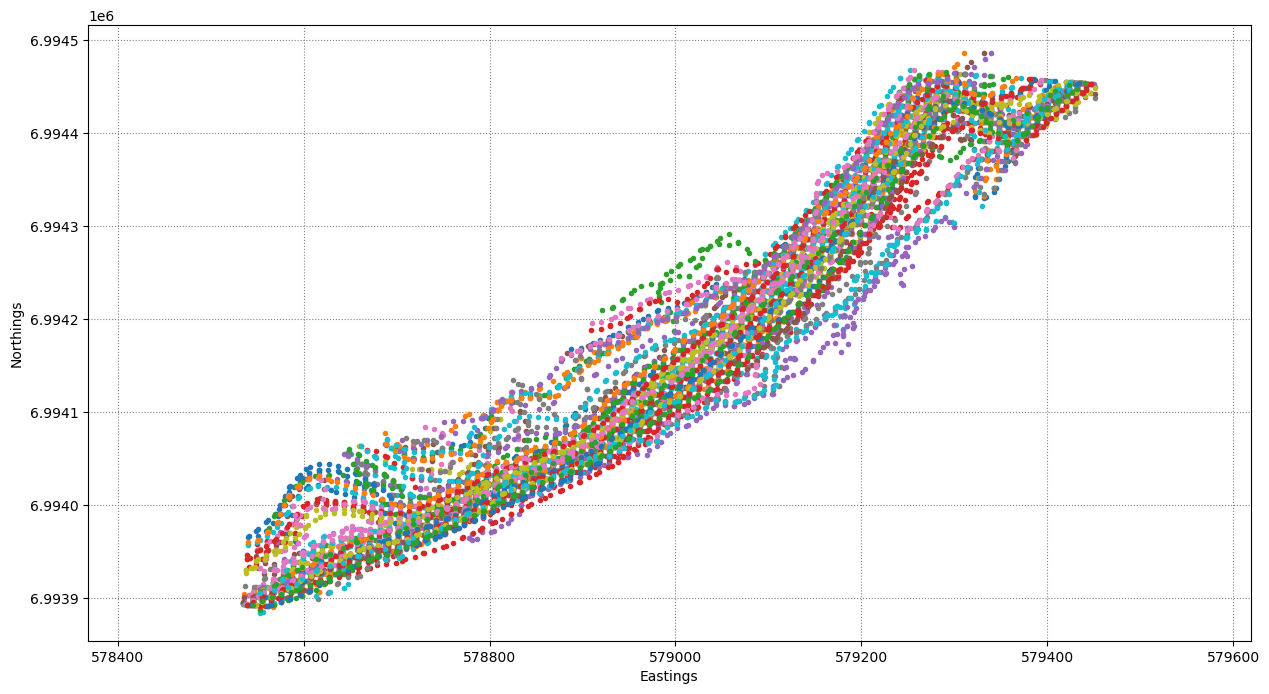

In [120]:
%matplotlib inline
fig = plt.figure(figsize=[15,8])
plt.axis('equal')
plt.xlabel('Eastings')
plt.ylabel('Northings')
plt.grid(linestyle=':', color='0.5')
for i in range(len(output['shorelines'])):
    sl = output['shorelines'][i]
    date = output['dates'][i]
    plt.plot(sl[:,0], sl[:,1], '.', label=date.strftime('%d-%m-%Y'));

## Shoreline analysis

In this section we show how to compute time-series of cross-shore distance along user-defined shore-normal transects.

**If you have already mapped the shorelines**, just load the output file (`output.pkl`) by running the section below

In [121]:
filepath = os.path.join(inputs['filepath'], sitename)
with open(os.path.join(filepath, sitename + '_output' + '.pkl'), 'rb') as f:
    output = pickle.load(f)
# remove duplicates (images taken on the same date by the same satellite)
output = SDS_tools.remove_duplicates(output)
# remove inaccurate georeferencing (set threshold to 10 m)
output = SDS_tools.remove_inaccurate_georef(output, 10)

# save .pkl when  duplicates iamges and inaccurate georeferencing are deleted 
with open(os.path.join(inputs['filepath'], sitename, sitename + '_output_removed_dup_geo' + '.pkl'), 'wb') as f:
    pickle.dump(output, f)

2 duplicates
2 bad georef


There are 3 options to define the coordinates of the shore-normal transects:

**Option 1**: the user can interactively draw the shore-normal transects along the beach by calling:

In [122]:
%matplotlib qt
transects = SDS_transects.draw_transects(output, settings)

Transect locations saved in c:\Users\bamba\COAST_AI\CoastSat\data\CRIEL_3


**Option 2**: the user can load the transect coordinates (make sure the coordinate reference system (CRS) is the same as defined previously in `settings['output_epsg]`) from a .geojson file by calling:

In [80]:
geojson_file = os.path.join(os.getcwd(), inputs['filepath'], inputs['sitename'], '%s_transects.geojson'%inputs['sitename'])
transects = SDS_tools.transects_from_geojson(geojson_file)

4 transects have been loaded coordinates are in epsg:2154


**Option 3**: manually provide the coordinates of the transects (in the same CRS as defined in `settings['output_epsg]` as shown in the example below:

In [ ]:
#transects = dict([])
#transects['NA1'] = np.array([[ 342880, 6269180 ], [ 343144, 6269037 ]])
#transects['NA2'] = np.array([[ 342733, 6268783 ], [ 343008, 6268664 ]])
#transects['NA3'] = np.array([[ 342451, 6267913 ], [ 342746, 6267859 ]])
#transects['NA4'] = np.array([[ 342460, 6267042 ], [ 342759, 6267075 ]])
#transects['NA5'] = np.array([[ 342675, 6266241 ], [ 342936, 6266388 ]])

Plot the location of the transects, make sure they are in the right location with the origin always landwards! Also check that the transects are intersecting the mapped shorelines.

In [123]:
fig = plt.figure(figsize=[15,8], tight_layout=True)
plt.axis('equal')
plt.xlabel('Eastings')
plt.ylabel('Northings')
plt.grid(linestyle=':', color='0.5')
for i in range(len(output['shorelines'])):
    sl = output['shorelines'][i]
    date = output['dates'][i]
    plt.plot(sl[:,0], sl[:,1], '.', label=date.strftime('%d-%m-%Y'))
for i,key in enumerate(list(transects.keys())):
    plt.plot(transects[key][0,0],transects[key][0,1], 'bo', ms=5)
    plt.plot(transects[key][:,0],transects[key][:,1],'k-',lw=1)
    plt.text(transects[key][0,0]-100, transects[key][0,1]+100, key,
                va='center', ha='right', bbox=dict(boxstyle="square", ec='k',fc='w'))
fig.savefig(os.path.join(filepath,'%s_mapped_shorelines.jpg'%sitename),dpi=200)

Now, we intersect 2D shorelines with the shore-normal transects to obtain time-series of cross-shore distance along each transect.

One way is to simply compute the intersection as the median of the shoreline points within a certain range (`along_dist`).

In [124]:
# along-shore distance over which to consider shoreline points to compute the median intersection
settings_transects = {'along_dist':25}
cross_distance = SDS_transects.compute_intersection(output, transects, settings_transects) 

However, the shorelines can often be noisy (small loops, double intersections, etc), therefore a few parameters can be set to quality-control the intersections between tranects and shorelines with a more advanced function `compute_intersection_QC()`:
- `along_dist`: (in metres),
    alongshore distance to caluclate the intersection (median of points 
    within this distance). 
- `min_points`:  minimum number of shoreline points to calculate an intersection.
- `max_std`: (in metres) maximum STD for the shoreline points within the alongshore range, 
    if STD is above this value a NaN is returned for this intersection.
- `max_range`: (in metres) maximum RANGE for the shoreline points within the alongshore range, 
    if RANGE is above this value a NaN is returned for this intersection.
- `min_chainage`: (in metres) furthest distance landward of the transect origin that an intersection is 
    accepted, beyond this point a NaN is returned.
- `multiple_inter`: ('auto','nan','max') defines how to deal with multiple shoreline intersections
- `auto_prc`: (value between 0 and 1) by default 0.1, percentage of the time that a multiple intersection needs to be present to use the max in auto mode

Default parameters for the more quality-controlled intersections are provided below and should work in most cases (leave as it is if unsure).

The `multiple_inter` setting helps to deal with multiple shoreline intersections along the same transect. This is quite common, for example when there is a lagoon behind the beach and the transect crosses two water bodies. The function will try to identify this cases and the user can choose whether to:
- `'nan'`: always assign a NaN when there are multile intersections.
- `'max'`: always take the max (intersection the furtherst seaward).
- `'auto'`: let the function decide transect by transect, and if it thinks there are two water bodies, take the max.
If `'auto'` is chosen, the `auto_prc` parameter will define when to use the max, by default it is set to 0.1, which means that the function thinks there are two water bodies if 10% of the time-series show multiple intersections.

In [125]:
settings_transects = { # parameters for computing intersections
                      'along_dist':          25,        # along-shore distance to use for computing the intersection
                      'min_points':          3,         # minimum number of shoreline points to calculate an intersection
                      'max_std':             15,        # max std for points around transect
                      'max_range':           30,        # max range for points around transect
                      'min_chainage':        -100,      # largest negative value along transect (landwards of transect origin)
                      'multiple_inter':      'auto',    # mode for removing outliers ('auto', 'nan', 'max')
                      'auto_prc':            0.1,       # percentage of the time that multiple intersects are present to use the max
                     }
cross_distance = SDS_transects.compute_intersection_QC(output, transects, settings_transects) 

Plot the time-series of shoreline change along each transect

In [126]:
fig = plt.figure(figsize=[15,8], tight_layout=True)
gs = gridspec.GridSpec(len(cross_distance),1)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95, hspace=0.05)
for i,key in enumerate(cross_distance.keys()):
    if np.all(np.isnan(cross_distance[key])):
        continue
    idx_nan = np.isnan(cross_distance[key])
    dates = [output['dates'][_] for _ in np.where(~idx_nan)[0]]
    chainage = cross_distance[key][~idx_nan]
    ax = fig.add_subplot(gs[i,0])
    ax.grid(linestyle=':', color='0.5')
    ax.plot(dates, chainage, '-o', ms=6, mfc='w')
    ax.set_ylabel('distance [m]', fontsize=12)
    ax.text(0.5,0.95, key, bbox=dict(boxstyle="square", ec='k',fc='w'), ha='center',
            va='top', transform=ax.transAxes, fontsize=14)
fig.savefig(os.path.join(filepath,'%s_timeseries_raw.jpg'%sitename),dpi=200)

In [127]:
# save a .csv file for Excel users
out_dict = dict([])
out_dict['dates'] = output['dates']
for key in transects.keys():
    out_dict[key] = cross_distance[key]
df = pd.DataFrame(out_dict)
fn = os.path.join(filepath,'%s_time_series_raw.csv'%sitename)
df.to_csv(fn, sep=',')
print('Time-series of the shoreline change along the transects saved as:\n%s'%fn)

Time-series of the shoreline change along the transects saved as:
c:\Users\bamba\COAST_AI\CoastSat\data\CRIEL_3\CRIEL_3_time_series_raw.csv


## Tidal correction

This section shows how to tidally-correct the extracted time-series of shoreline change using time-series of tide level and an estimate of the beach slope.

For this example, measured water levels for Sydney are stored in a csv file located [here](https://github.com/kvos/CoastSat/blob/master/examples/NARRA_tides.csv) and we assume that the beach slope at Narrabeen-Collaroy is 0.1 along all transects.

If you are running a different site, you have two options to get the tide levels:
- **Option 1**: use the [FES2022](https://www.aviso.altimetry.fr/en/data/products/auxiliary-products/global-tide-fes/release-fes22.html) global tide model to predict tide levels at the time of image acquisition. To setup FES2022 on your machine follow the instructions in [this document](https://github.com/kvos/CoastSat/blob/master/doc/FES2022_setup.md).
- **Option 2**: provide your own tide level time-series. When using your own file make sure that the dates are in UTC time, as the CoastSat shorelines are also in UTC, and the datum for the water levels is approx. Mean Sea Level.

We will also see further down how to estimate beach slopes using the [CoastSat.slope](https://github.com/kvos/CoastSat.slope) methodology (integrated here).

**Option 1:** use FES2022 to predict tides

The cell below will load the netcdf files with the global tidal constituents (34 for ocean tides and 34 for loadings) that will then be used to predict tide levels. This takes a few minutes, and if you run into an OutOfMemory error (not enough RAM available to load the files), there is a solution. Go to /examples/tide_model_clipping and run `clip_tide_files.py` to clip the netcdf files to a polygon in order to reduce their size and be able to load them smoothly.

In [13]:
# import coastsat.slope module
from coastsat import SDS_slope
# load pyfes and the global tide model (may take one minute)
import pyfes
filepath_FES = os.path.join('fes2022b')
config =  os.path.join(filepath_FES, 'fes2022.yaml')
handlers = pyfes.load_config(config)
ocean_tide = handlers['tide']
load_tide = handlers['radial'] 

In [62]:
# get polygon centroid, coordinates to get tides from
centroid = np.mean(polygon[0], axis=0)
print(centroid)
# if longitude is negative add 180 (longitudes are from 0 to 360 in fes)
if centroid[0] < 0: centroid[0] += 360

[-1.13102145 45.51225704]


In [63]:
#reset filepath name 
filepath = os.path.join(inputs['filepath'], sitename)
# get tides time-series (2 values per day)
date_range = [pytz.utc.localize(datetime.strptime(inputs['dates'][0],'%Y-%m-%d')),
              pytz.utc.localize(datetime.strptime(inputs['dates'][1],'%Y-%m-%d'))]
timestep = 86400/4 # seconds (2 values per day)
dates_ts, tides_ts = SDS_slope.compute_tide(centroid, date_range, timestep, ocean_tide, load_tide)
# get tide levels corresponding to the time of image acquisition
dates_sat = output['dates']
tides_sat = SDS_slope.compute_tide_dates(centroid, output['dates'], ocean_tide, load_tide)
# plot the subsampled tide data
fig, ax = plt.subplots(1,1,figsize=(15,4), tight_layout=True)
ax.grid(which='major', linestyle=':', color='0.5')
ax.plot(dates_ts, tides_ts, '-', color='0.6', label='all time-series')
ax.plot(dates_sat, tides_sat, '-o', color='k', ms=6, mfc='w',lw=1, label='image acquisition')
ax.set(ylabel='tide level [m]',xlim=[dates_sat[0],dates_sat[-1]], title='Tide levels at the time of image acquisition');
ax.legend()
fig.savefig(os.path.join(filepath,'%s_tide_timeseries.jpg'%sitename),dpi=200)

You can also save the prediced tide time-series into a .csv file for later use by uncommenting this cell.

In [64]:
tide_data = {'dates':dates_ts,'tide':tides_ts}
df = pd.DataFrame(tide_data)
df.to_csv(os.path.join(os.getcwd(),'examples','%s_tides.csv'%sitename),index=False)

**Option 2:** use a local file with tide levels (one example is provided for Narrabeen-Collaroy)

In [49]:
# #load the measured tide data
# filepath = os.path.join(os.getcwd(),'examples','%s_tides.csv'%sitename)
# tide_data = pd.read_csv(filepath)
# dates_ts = [pd.to_datetime(_).to_pydatetime() for _ in tide_data['dates']]
# tides_ts = np.array(tide_data['tide'])

# #get tide levels corresponding to the time of image acquisition
# dates_sat = output['dates']
# tides_sat = SDS_tools.get_closest_datapoint(dates_sat, dates_ts, tides_ts)

# #plot the subsampled tide data
# fig, ax = plt.subplots(1,1,figsize=(15,4), tight_layout=True)
# ax.grid(which='major', linestyle=':', color='0.5')
# ax.plot(dates_ts, tides_ts, '-', color='0.6', label='all time-series')
# ax.plot(dates_sat, tides_sat, '-o', color='k', ms=6, mfc='w',lw=1, label='image acquisition')
# ax.set(ylabel='tide level [m]',xlim=[dates_sat[0],dates_sat[-1]], title='Tide levels at the time of image acquisition');
# ax.legend()
# fig.savefig(os.path.join(inputs['filepath'], sitename, '%s_tide_timeseries.jpg'%sitename),dpi=200)

Apply tidal correction using a linear slope and a reference elevation to which project all the time-series of cross-shore change (to get time-series at Mean Sea Level, set `reference_elevation` to 0. You also need an estimate of the beach slope. 

In [65]:
#reset filepath name 
filepath = os.path.join(inputs['filepath'], sitename)

# tidal correction along each transect
reference_elevation = 0 # elevation at which you would like the shoreline time-series to be
beach_slope = 0.029 # for SOULAC
cross_distance_tidally_corrected = {}
for key in cross_distance.keys():
    correction = (tides_sat-reference_elevation)/beach_slope
    cross_distance_tidally_corrected[key] = cross_distance[key] + correction
    
# store the tidally-corrected time-series in a .csv file
out_dict = dict([])
out_dict['dates'] = dates_sat
for key in cross_distance_tidally_corrected.keys():
    out_dict[key] = cross_distance_tidally_corrected[key]
df = pd.DataFrame(out_dict)
fn = os.path.join(inputs['filepath'], sitename, 'transect_time_series_tidally_corrected.csv')
df.to_csv(fn, sep=',')
print('Tidally-corrected time-series of the shoreline change along the transects saved as:\n%s'%fn)

# plot the time-series of shoreline change (both raw and tidally-corrected)
fig = plt.figure(figsize=[15,8], tight_layout=True)
gs = gridspec.GridSpec(len(cross_distance),1)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95, hspace=0.05)
for i,key in enumerate(cross_distance.keys()):
    if np.all(np.isnan(cross_distance[key])):
        continue
    idx_nan = np.isnan(cross_distance[key])
    dates = [output['dates'][_] for _ in np.where(~idx_nan)[0]]
    chainage = cross_distance[key][~idx_nan]
    chainage_corrected = cross_distance_tidally_corrected[key][~idx_nan]
    ax = fig.add_subplot(gs[i,0])
    ax.grid(linestyle=':', color='0.5')
    ax.plot(dates, chainage, '-o', ms=6, mfc='w', label='raw')
    ax.plot(dates, chainage_corrected, '-o', ms=6, mfc='w', label='tidally-corrected')
    ax.set_ylabel('distance [m]', fontsize=12)
    ax.text(0.5,0.95, key, bbox=dict(boxstyle="square", ec='k',fc='w'), ha='center',
            va='top', transform=ax.transAxes, fontsize=14)
    
    
ax.legend()
fig.savefig(os.path.join(inputs['filepath'],sitename,'%s_timeseries_corrected.jpg'%sitename),dpi=200)

Tidally-corrected time-series of the shoreline change along the transects saved as:
c:\Users\bamba\COAST_AI\CoastSat\data\SOULAC_2\transect_time_series_tidally_corrected.csv


## Time-series post-processing

Finally, we can post-process the time-series of shoreline change to remove obvious outliers and spikes in the data and average the time-series over different time-frames (seasonally or monthly).

To demonstrate these functionalities, we load a full time-series of shoreline change at Narrabeen from Landsat imagery between 1984 and 2021. These shorelines were mapped automatically without manual quality control, intersected with the transects and tidally-corrected.

In [66]:
# load mapped shorelines from 1984
# filename_output = os.path.join(os.getcwd(),'examples','NARRA_output.pkl')
filename_output = os.path.join(inputs['filepath'],sitename,sitename + '_output_removed_dup_geo' + '.pkl')
with open(filename_output, 'rb') as f:
    output = pickle.load(f) 

# plot the mapped shorelines
fig = plt.figure(figsize=[15,8], tight_layout=True)
plt.axis('equal')
plt.xlabel('Eastings')
plt.ylabel('Northings')
plt.grid(linestyle=':', color='0.5')
plt.title('%d shorelines mapped at Soulac-sur-mer from 1984'%len(output['shorelines']))
for i in range(len(output['shorelines'])):
    sl = output['shorelines'][i]
    date = output['dates'][i]
    plt.plot(sl[:,0], sl[:,1], '.', label=date.strftime('%d-%m-%Y'))
for i,key in enumerate(list(transects.keys())):
    plt.plot(transects[key][0,0],transects[key][0,1], 'bo', ms=5)
    plt.plot(transects[key][:,0],transects[key][:,1],'k-',lw=1)
    plt.text(transects[key][0,0]-100, transects[key][0,1]+100, key,
             va='center', ha='right', bbox=dict(boxstyle="square", ec='k',fc='w'))
fig.savefig(os.path.join(inputs['filepath'],sitename,'%s_output_shoreline_for_postprocessing.jpg'%sitename),dpi=200)

# load long time-series (1984-2025)
# filename_ts = os.path.join(os.getcwd(),'examples','NARRA_time_series_tidally_corrected.csv')
filename_ts = os.path.join(inputs['filepath'],sitename, 'transect_time_series_tidally_corrected.csv')
df = pd.read_csv(filename_ts, parse_dates=['dates'])
dates = [_.to_pydatetime() for _ in df['dates']]
cross_distance = dict([])
for key in transects.keys():
    cross_distance[key] = np.array(df[key])
    

### Despiking the time-series

The tidally-corrected time-series of shoreline change obtained with the steps above may still contain some outliers (from cloud shadows, false detections etc). The function `SDS_transects.reject_outliers()` was developed to remove obvious outliers in the time-series, by removing the points that do not make physical sense in a shoreline change setting. 

For example, the shoreline can experience rapid erosion after a large storm, but it will then take time to recover and return to its previous state. Therefore, if the shoreline erodes/accretes suddenly of a significant amount (`max_cross_change`) and then immediately returns to its previous state, this spike does not make any physical sense and can be considered an outlier. Additionally, this function also checks that the Otsu thresholds used to map the shoreline are within the typical range defined by `otsu_threshold`, with values outside this range identified as outliers.

In [67]:
# remove outliers in the time-series (coastal despiking)
settings_outliers = {'max_cross_change':   100,             # maximum cross-shore change observable between consecutive timesteps
                     'otsu_threshold':     [-.5,0],        # min and max intensity threshold use for contouring the shoreline
                     'plot_fig':           True,           # whether to plot the intermediate steps
                    }
cross_distance = SDS_transects.reject_outliers(cross_distance_tidally_corrected,output,settings_outliers)

1  - outliers removed: 41
2  - outliers removed: 72
3  - outliers removed: 147
4  - outliers removed: 84
5  - outliers removed: 49


We can also plot the Otsu threholds for the shorelines mapped at this site to see if there are any obvious outliers and adjust the values of `otsu_threshold`.

In [69]:
# plot Otsu thresholds for the mapped shorelines
fig,ax = plt.subplots(1,1,figsize=[12,5],tight_layout=True)
ax.grid(which='major',ls=':',lw=0.5,c='0.5')
ax.plot(output['dates'],output['MNDWI_threshold'],'o-',mfc='w')
ax.axhline(y=-0.5,ls='--',c='r',label='otsu_threshold limits')
ax.axhline(y=0,ls='--',c='r')
ax.set(title='Otsu thresholds on MNDWI for the %d shorelines mapped'%len(output['shorelines']),
       ylim=[-0.6,0.2],ylabel='otsu threshold')
ax.legend(loc='upper left')
fig.savefig(os.path.join(filepath,'%s_otsu_threhsolds.jpg'%sitename), dpi=200)

In [ ]:
# # Add by Bamba to  load the correction of tides after despiking outliers 
# #reset filepath name 
# filepath = os.path.join(inputs['filepath'], sitename)

# # tidal correction along each transect
# reference_elevation = 0 # elevation at which you would like the shoreline time-series to be
# beach_slope = 0.1
# cross_distance_tidally_corrected = {}
# for key in cross_distance.keys():
#     correction = (tides_sat-reference_elevation)/beach_slope
#     cross_distance_tidally_corrected[key] = cross_distance[key] + correction
    
# # store the tidally-corrected time-series in a .csv file
# out_dict = dict([])
# out_dict['dates'] = dates_sat
# for key in cross_distance_tidally_corrected.keys():
#     out_dict[key] = cross_distance_tidally_corrected[key]
# df = pd.DataFrame(out_dict)
# fn = os.path.join(inputs['filepath'], sitename, 'transect_time_series_tidally_corrected_without_outliers.csv')
# df.to_csv(fn, sep=',')
# print('Tidally-corrected time-series of the shoreline change along the transects saved as:\n%s'%fn)

# # plot the time-series of shoreline change (both raw and tidally-corrected)
# fig = plt.figure(figsize=[15,8], tight_layout=True)
# gs = gridspec.GridSpec(len(cross_distance),1)
# gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95, hspace=0.05)
# for i,key in enumerate(cross_distance.keys()):
#     if np.all(np.isnan(cross_distance[key])):
#         continue
#     idx_nan = np.isnan(cross_distance[key])
#     dates = [output['dates'][_] for _ in np.where(~idx_nan)[0]]
#     chainage = cross_distance[key][~idx_nan]
#     chainage_corrected = cross_distance_tidally_corrected[key][~idx_nan]
#     ax = fig.add_subplot(gs[i,0])
#     ax.grid(linestyle=':', color='0.5')
#     ax.plot(dates, chainage, '-o', ms=6, mfc='w', label='raw')
#     ax.plot(dates, chainage_corrected, '-o', ms=6, mfc='w', label='tidally-corrected')
#     ax.set_ylabel('distance [m]', fontsize=12)
#     ax.text(0.5,0.95, key, bbox=dict(boxstyle="square", ec='k',fc='w'), ha='center',
#             va='top', transform=ax.transAxes, fontsize=14)
    
    
# ax.legend()
# fig.savefig(os.path.join(inputs['filepath'],sitename,'%s_timeseries_corrected_without_outliers.jpg'%sitename),dpi=200)

Tidally-corrected time-series of the shoreline change along the transects saved as:
c:\Users\bamba\COAST_AI\CoastSat\data\SOULAC_2\transect_time_series_tidally_corrected_without_outliers.csv


### Seasonal averaging and long-term trends

The cell below shows how to calculate seasonal averages on the time-series with `SDS_transects.seasonal_average()` and calculate the long-term trend with `SDS_transects.calculate_trend()`.

In [70]:
fp_seasonal = os.path.join(filepath,'jpg_files','seasonal_timeseries')
if not os.path.exists(fp_seasonal): os.makedirs(fp_seasonal)
print('Outputs will be saved in %s'%fp_seasonal)
season_colors = {'DJF':'C3', 'MAM':'C1', 'JJA':'C2', 'SON':'C0'}
for key in cross_distance.keys():
    chainage = cross_distance[key]
    # remove nans
    idx_nan = np.isnan(chainage)
    dates_nonan = [dates[_] for _ in np.where(~idx_nan)[0]]
    chainage = chainage[~idx_nan] 
    
    # compute shoreline seasonal averages (DJF, MAM, JJA, SON)
    dict_seas, dates_seas, chainage_seas, list_seas = SDS_transects.seasonal_average(dates_nonan, chainage)
    
    # calculate long-term trend
    trend, y =  SDS_transects.calculate_trend(dates_seas, chainage_seas)
    
    # plot seasonal averages
    fig,ax=plt.subplots(1,1,figsize=[14,4],tight_layout=True)
    ax.grid(which='major', linestyle=':', color='0.5')
    ax.set_title('Time-series at %s'%key, x=0, ha='left')
    ax.set(ylabel='distance [m]')
    ax.plot(dates_nonan, chainage,'+', lw=1, color='k', mfc='w', ms=4, alpha=0.5,label='raw datapoints')
    ax.plot(dates_seas, chainage_seas, '-', lw=1, color='k', mfc='w', ms=4, label='seasonally-averaged')
    for k,seas in enumerate(dict_seas.keys()):
        ax.plot(dict_seas[seas]['dates'], dict_seas[seas]['chainages'],
                 'o', mec='k', color=season_colors[seas], label=seas,ms=5)
    ax.plot(dates_seas,y,'--',color='b', label='trend %.1f m/year'%trend)
    ax.legend(loc='lower left',ncol=7,markerscale=1.5,frameon=True,edgecolor='k',columnspacing=1)
    fig.savefig(os.path.join(fp_seasonal,'%s_timeseries_seasonal.jpg'%key), dpi=200)

Outputs will be saved in c:\Users\bamba\COAST_AI\CoastSat\data\SOULAC_2\jpg_files\seasonal_timeseries


### Monthly averages

The cell below shows how to calculate seasonal averages on the time-series with `SDS_transects.monthly_average()` and plot them.

In [71]:
fp_monthly = os.path.join(filepath,'jpg_files','monthly_timeseries')
if not os.path.exists(fp_monthly): os.makedirs(fp_monthly)
print('Outputs will be saved in %s'%fp_monthly)
month_colors = plt.get_cmap('tab20')
for key in cross_distance.keys():
    chainage = cross_distance[key]
    # remove nans
    idx_nan = np.isnan(chainage)
    dates_nonan = [dates[_] for _ in np.where(~idx_nan)[0]]
    chainage = chainage[~idx_nan] 
    
    # compute shoreline monthly averages
    dict_month, dates_month, chainage_month, list_month = SDS_transects.monthly_average(dates_nonan, chainage)
    
    # plot monthly averages
    fig,ax=plt.subplots(1,1,figsize=[14,4],tight_layout=True)
    ax.grid(which='major', linestyle=':', color='0.5')
    ax.set_title('Time-series at %s'%key, x=0, ha='left')
    ax.set(ylabel='distance [m]')
    ax.plot(dates_nonan, chainage,'+', lw=1, color='k', mfc='w', ms=4, alpha=0.5,label='raw datapoints')
    ax.plot(dates_month, chainage_month, '-', lw=1, color='k', mfc='w', ms=4, label='monthly-averaged')
    for k,month in enumerate(dict_month.keys()):
        ax.plot(dict_month[month]['dates'], dict_month[month]['chainages'],
                 'o', mec='k', color=month_colors(k), label=month,ms=5)
    ax.legend(loc='lower left',ncol=7,markerscale=1.5,frameon=True,edgecolor='k',columnspacing=1)
    fig.savefig(os.path.join(fp_monthly,'%s_timeseries_monthly.jpg'%key), dpi=200)

Outputs will be saved in c:\Users\bamba\COAST_AI\CoastSat\data\SOULAC_2\jpg_files\monthly_timeseries


## Beach slope estimation

This section uses the same long-term time-series of shoreline change to demonstrate how to estimate the beach-face slope. 

More details on the slope estimation methodology are [Vos et al. 2020](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2020GL088365) and [Vos et al. 2022](https://essd.copernicus.org/articles/14/1345/2022/). 

For a more detailed tutorial visit the [CoastSat.slope repository](https://github.com/kvos/CoastSat.slope/tree/master).


In [38]:
# create folder to save outputs from slope estimation
fp_slopes = os.path.join(filepath,'slope_estimation')
if not os.path.exists(fp_slopes):
    os.makedirs(fp_slopes)
print('Outputs will be saved in %s'%fp_slopes)

Outputs will be saved in c:\Users\bamba\COAST_AI\CoastSat\data\SOULAC_2\slope_estimation


To estimate slopes we need the long-term Landsat satellite-derived shorelines that we have used above inthe **Time-series post-processing** section. To estimate the slopes we need to do the following:
- load the shorelines file provided `NARRA_output.pkl`, all Landsat shorelines
-  compute the intersections with `SDS_transects.compute_intersection_QC()`
-  remove the outliers in the time-series with `SDS_transects.reject_outliers()`

In [39]:
# load mapped shorelines from 1984 using Landsat 5, 7 and 8
#filename_output = os.path.join(os.getcwd(),'examples','NARRA_output.pkl')
filename_output = os.path.join(inputs['filepath'],sitename,sitename + '_output' + '.pkl')

with open(filename_output, 'rb') as f:
    output = pickle.load(f) 
# remove duplicates (images taken on the same date by the same satellite)
output = SDS_tools.remove_duplicates(output)
# remove inaccurate georeferencing (set threshold to 10 m)
output = SDS_tools.remove_inaccurate_georef(output, 10)
# compute intersections 
settings_transects = { # parameters for computing intersections
                      'along_dist':          25,        # along-shore distance to use for computing the intersection
                      'min_points':          3,         # minimum number of shoreline points to calculate an intersection
                      'max_std':             15,        # max std for points around transect
                      'max_range':           30,        # max range for points around transect
                      'min_chainage':        -100,      # largest negative value along transect (landwards of transect origin)
                      'multiple_inter':      'auto',    # mode for removing outliers ('auto', 'nan', 'max')
                      'auto_prc':            0.1,       # percentage of the time that multiple intersects are present to use the max
                     }
cross_distance = SDS_transects.compute_intersection_QC(output, transects, settings_transects) 
# remove outliers in the time-series (coastal despiking)
settings_outliers = {'max_cross_change':   40,             # maximum cross-shore change observable between consecutive timesteps
                     'otsu_threshold':     [-.5,0],        # min and max intensity threshold use for contouring the shoreline
                     'plot_fig':           False,           # whether to plot the intermediate steps
                    }
cross_distance = SDS_transects.reject_outliers(cross_distance,output,settings_outliers)

220 duplicates
235 bad georef
************************1  - outliers removed: 416
************************2  - outliers removed: 409
**********************3  - outliers removed: 436
*************4  - outliers removed: 353
********5  - outliers removed: 234


Now we plot the time-series to check that we have done everything correctly

In [40]:
# plot time-series
from coastsat import SDS_slope
SDS_slope.plot_cross_distance(output['dates'],cross_distance)

We define the slope estimation settings. This includes the range of slopes that we will test for (min and max) as well as some specific parameters (see [CoastSat.slope](https://github.com/kvos/CoastSat.slope/tree/master) for more info)

In [41]:
# slope estimation settings
days_in_year = 365.2425
seconds_in_day = 24*3600
settings_slope = {'slope_min':        0.01,                  # minimum slope to trial
                  'slope_max':        0.2,                    # maximum slope to trial
                  'delta_slope':      0.005,                  # slope increment
                  'n0':               50,                     # parameter for Nyquist criterium in Lomb-Scargle transforms
                  'freq_cutoff':     1./(seconds_in_day*30), # 1 month frequency
                  'delta_f':          100*1e-10,              # deltaf for identifying peak tidal frequency band
                  'prc_conf':         0.05,                   # percentage above minimum to define confidence bands in energy curve
                  'plot_fig':         True,                   # whether to plot the intermediary products during analysis
                  }
# range of slopes to test for
beach_slopes = SDS_slope.range_slopes(settings_slope['slope_min'], settings_slope['slope_max'], settings_slope['delta_slope'])

Then we need to restrict the date range to the period in which we have at least to Landsat satellites in orbit simultaneously. This is generally from 1999 (launch of Landsat 7 to present).

In [42]:
# range of dates over which to perform the analysis (2 Landsat satellites)
settings_slope['date_range'] = [1999,2022]
# re-write in datetime objects (same as shoreline in UTC)
settings_slope['date_range'] = [pytz.utc.localize(datetime(settings_slope['date_range'][0],5,1)),
                                pytz.utc.localize(datetime(settings_slope['date_range'][1],1,1))]
# clip the time-series between 1999 and 2022 as we need at least 2 Landsat satellites 
idx_dates = [np.logical_and(_>settings_slope['date_range'][0],_<settings_slope['date_range'][1]) for _ in output['dates']]
dates_sat = [output['dates'][_] for _ in np.where(idx_dates)[0]]
for key in cross_distance.keys():
    cross_distance[key] = cross_distance[key][idx_dates]

Once we have clipped the time-series, we look at the timestep between observations and choose our Nyquist frequency (most common timestep). Generally that's 8 days as each Landsat satellite has a revisit of 16 days. But in some cases at the overlap between tiles it could be lower, for example 7 days. So let's plot it first.

In [43]:
SDS_slope.plot_timestep(dates_sat)
plt.gcf().savefig(os.path.join(fp_slopes,'0_timestep_distribution.jpg'),dpi=200)

Based on the plot above, we select 8 days sampling period

In [44]:
# sampling period [days]
settings_slope['n_days'] = 8

Now we get the tide level time-series

In [45]:
# get polygon centroid
centroid = np.mean(polygon[0], axis=0)
print(centroid)
# get tides time-series (15 minutes timestep)
date_range = [dates_sat[0], dates_sat[-1]]
timestep = 900 # seconds
dates_ts, tides_ts = SDS_slope.compute_tide(centroid, date_range, timestep, ocean_tide, load_tide)
# get tide levels corresponding to the time of image acquisition
tides_sat = SDS_slope.compute_tide_dates(centroid, dates_sat, ocean_tide, load_tide)
# plot the subsampled tide data
fig, ax = plt.subplots(1,1,figsize=(15,4), tight_layout=True)
ax.grid(which='major', linestyle=':', color='0.5')
ax.plot(dates_ts, tides_ts, '-', color='0.6', label='all time-series')
ax.plot(dates_sat, tides_sat, '-o', color='k', ms=5, mfc='w',lw=1, label='image acquisition')
ax.set(ylabel='tide level [m]',xlim=[dates_sat[0],dates_sat[-1]], title='Tide levels at the time of image acquisition');
ax.legend()
fig.savefig(os.path.join(fp_slopes,'0_tide_timeseries.jpg'),dpi=200)

[-1.13102145 45.51225704]


Find the peak tide frequency by performing a Lomb-Scargle transform (Power Spectrum Density for unevenly sampled data) on the tide time-series. With a Nyquist limit of 16 days (given the sampling period of 8 days), we will get a peak at 17.5 days, which is an aliased version of the 14.8 days spring-neap cycle.

In [46]:
settings_slope['freqs_max'] = SDS_slope.find_tide_peak(dates_sat,tides_sat,settings_slope)
plt.gcf().savefig(os.path.join(fp_slopes,'1_tides_power_spectrum.jpg'),dpi=200)

Finally, estimate the beach slope for each transect by finding the slope used for tidal correction that minimises the energy at the peak tide frequency

In [47]:
# estimate beach-face slopes along the transects
slope_est, cis = dict([]), dict([])
for key in cross_distance.keys():
    # remove NaNs
    idx_nan = np.isnan(cross_distance[key])
    dates = [dates_sat[_] for _ in np.where(~idx_nan)[0]]
    tide = tides_sat[~idx_nan]
    composite = cross_distance[key][~idx_nan]
    # apply tidal correction
    tsall = SDS_slope.tide_correct(composite,tide,beach_slopes)
    # estimate beach slope
    slope_est[key],cis[key] = SDS_slope.integrate_power_spectrum(dates,tsall,settings_slope, key)
    plt.gcf().savefig(os.path.join(fp_slopes,'2_energy_curve_%s.jpg'%key),dpi=200)
    # plot spectrums
    SDS_slope.plot_spectrum_all(dates,composite,tsall,settings_slope,slope_est[key])
    plt.gcf().savefig(os.path.join(fp_slopes,'3_slope_spectrum_%s.jpg'%key),dpi=200)
    print('Beach slope at transect %s: %.3f (%.4f - %.4f)'%(key, slope_est[key], cis[key][0], cis[key][1]))

Beach slope at transect 1: 0.020 (0.0200 - 0.0225)
Beach slope at transect 2: 0.025 (0.0250 - 0.0300)
Beach slope at transect 3: 0.020 (0.0200 - 0.0200)
Beach slope at transect 4: 0.025 (0.0250 - 0.0325)
Beach slope at transect 5: 0.055 (0.0450 - 0.0675)


## Validation against surveys

This section provides a validation of the satellite-derived shorelines at Narrabeen-Collaroy against the survey data, available at http://narrabeen.wrl.unsw.edu.au/download/narrabeen/.

First, you need to download the survey data from the website. Go to the website, click `Download data`, then create a new user and select `Narrabeen Profile Data` as shown below:

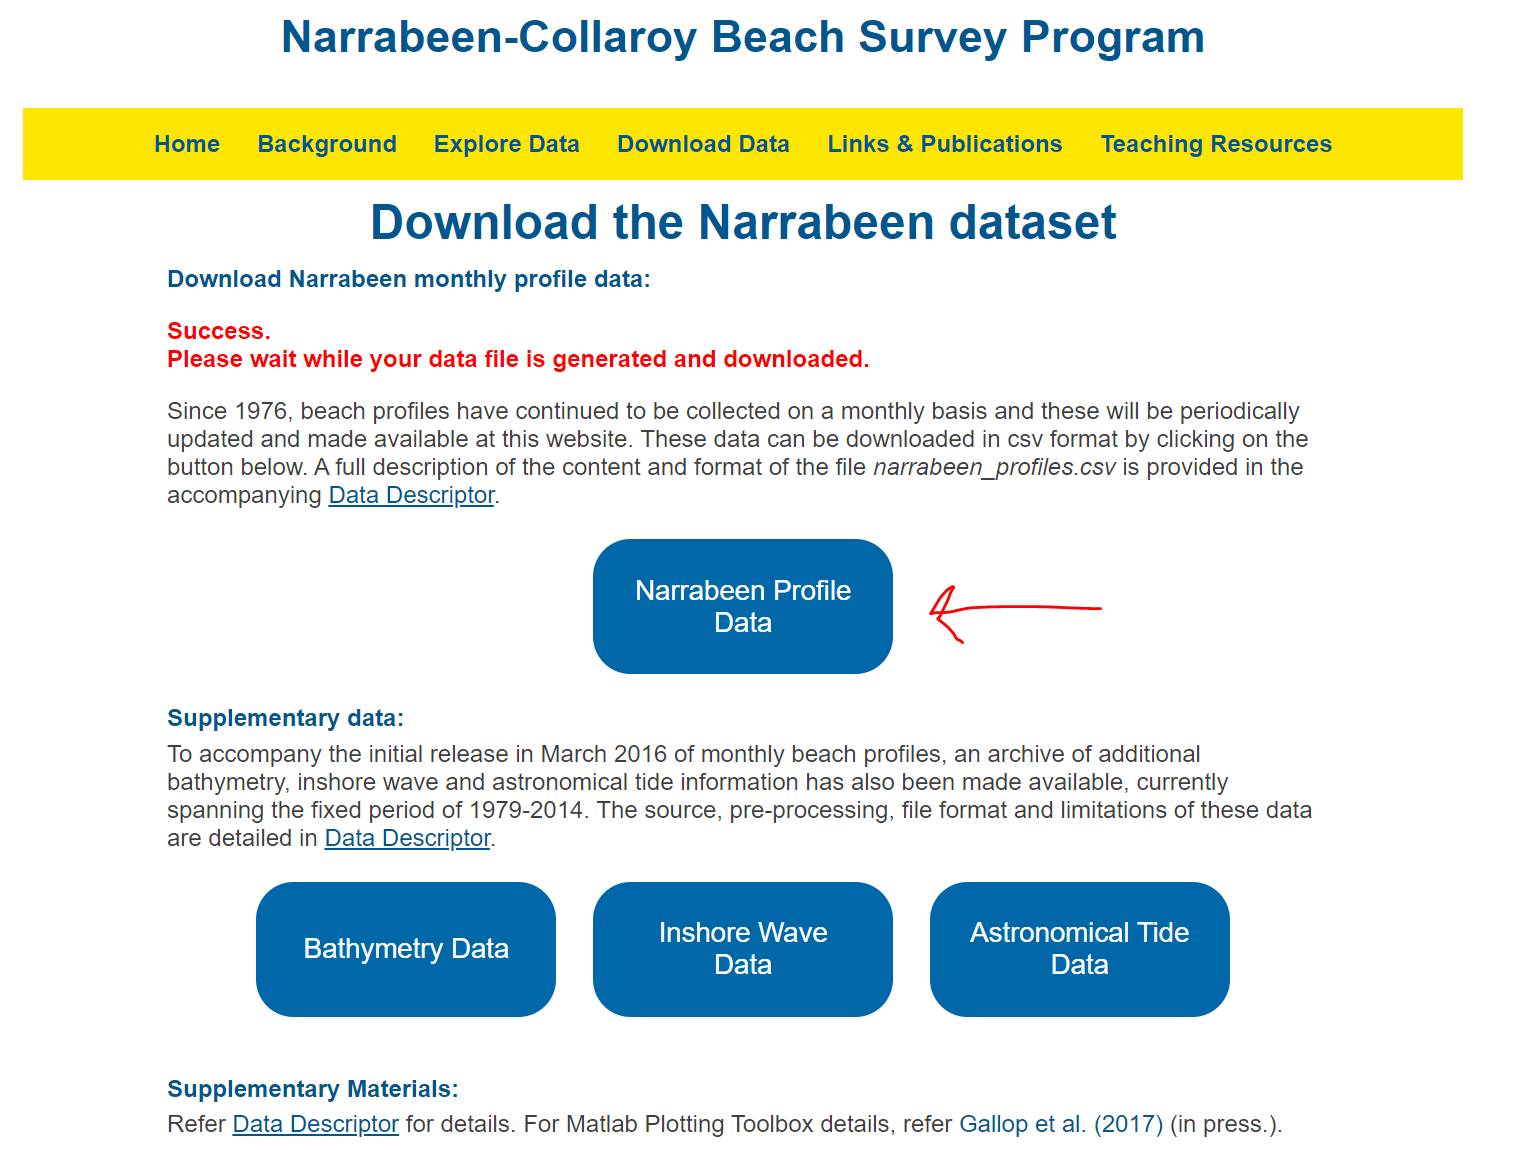

A csv file called `Narrabeen_profiles.csv` will be downloaded, copy it into the `./examples` folder. The code below is used to preprocess the data into time-series of shoreline change at a user-define contour level.

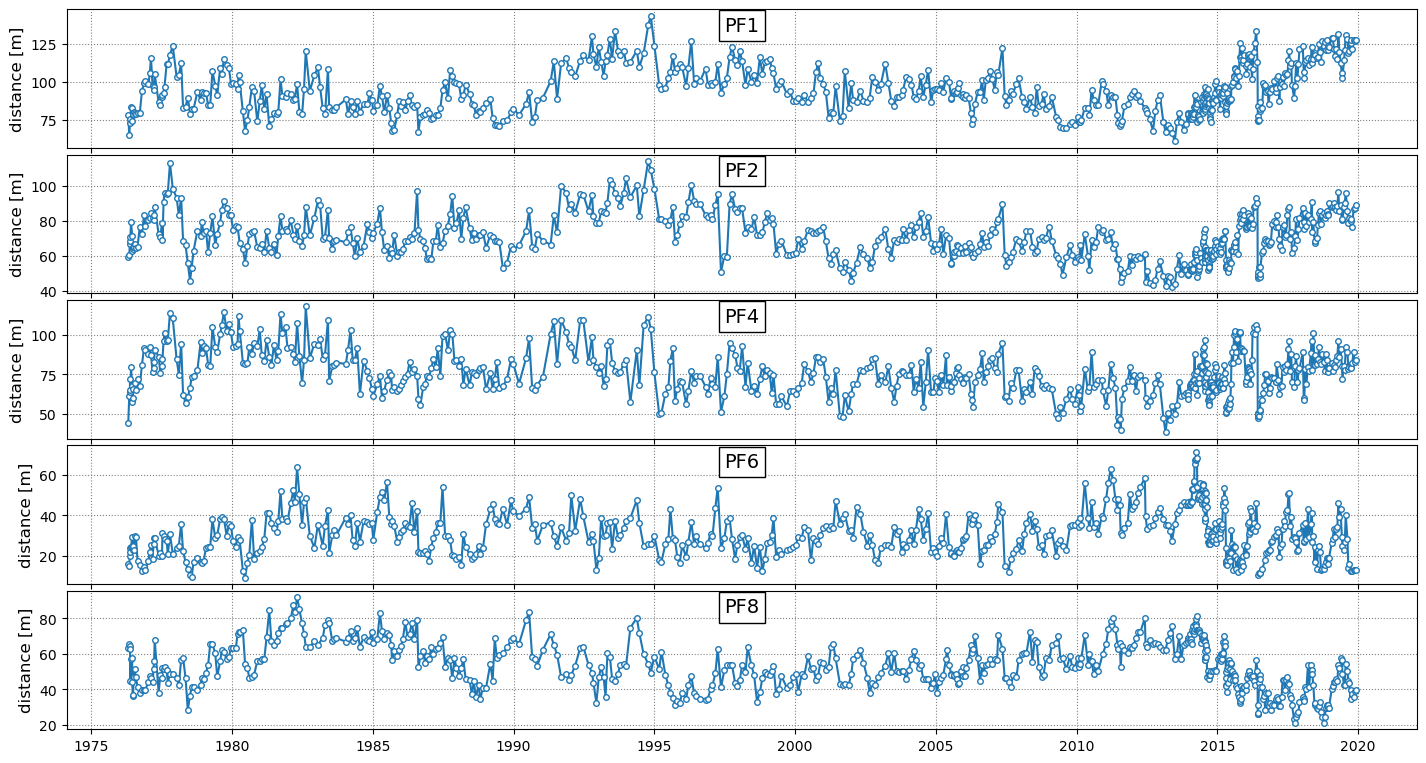

In [ ]:
from scipy import interpolate
from scipy import stats
from datetime import timedelta
import pytz
# read the csv file
fp_datasets = os.path.join(os.getcwd(),'examples','Narrabeen_Profiles.csv')
df = pd.read_csv(fp_datasets)
pf_names = list(np.unique(df['Profile ID']))

# select contour level
contour_level = 0.7

# initialise topo_profiles structure
topo_profiles = dict([])
for i in range(len(pf_names)):
     # read dates
    df_pf = df.loc[df['Profile ID'] == pf_names[i]]
    dates_str = df['Date']
    dates_unique = np.unique(dates_str)
    # loop through dates
    topo_profiles[pf_names[i]] = {'dates':[],'chainages':[]}
    for date in dates_unique:
        # extract chainage and elevation for that date
        df_date = df_pf.loc[dates_str == date]
        chainages = np.array(df_date['Chainage'])
        elevations = np.array(df_date['Elevation'])
        if len(chainages) == 0: continue
        # use interpolation to extract the chainage at the contour level
        f = interpolate.interp1d(elevations, chainages, bounds_error=False)
        chainage_contour_level = f(contour_level)
        topo_profiles[pf_names[i]]['chainages'].append(chainage_contour_level)
        date_utc = pytz.utc.localize(datetime.strptime(date,'%Y-%m-%d'))
        topo_profiles[pf_names[i]]['dates'].append(date_utc)

# plot time-series
fig = plt.figure(figsize=[15,8], tight_layout=True)
gs = gridspec.GridSpec(len(topo_profiles),1)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95, hspace=0.05)
for i,key in enumerate(topo_profiles.keys()):
    ax = fig.add_subplot(gs[i,0])
    ax.grid(linestyle=':', color='0.5')
    ax.plot(topo_profiles[key]['dates'], topo_profiles[key]['chainages'], '-o', ms=4, mfc='w')
    ax.set_ylabel('distance [m]', fontsize=12)
    ax.text(0.5,0.95, key, bbox=dict(boxstyle="square", ec='k',fc='w'), ha='center',
            va='top', transform=ax.transAxes, fontsize=14)  
# save a .pkl file
with open(os.path.join(os.getcwd(), 'examples', 'Narrabeen_ts_07m.pkl'), 'wb') as f:
    pickle.dump(topo_profiles, f)

Now compare the surveys to the satellite-derived shorelines from 1984 loaded previously.

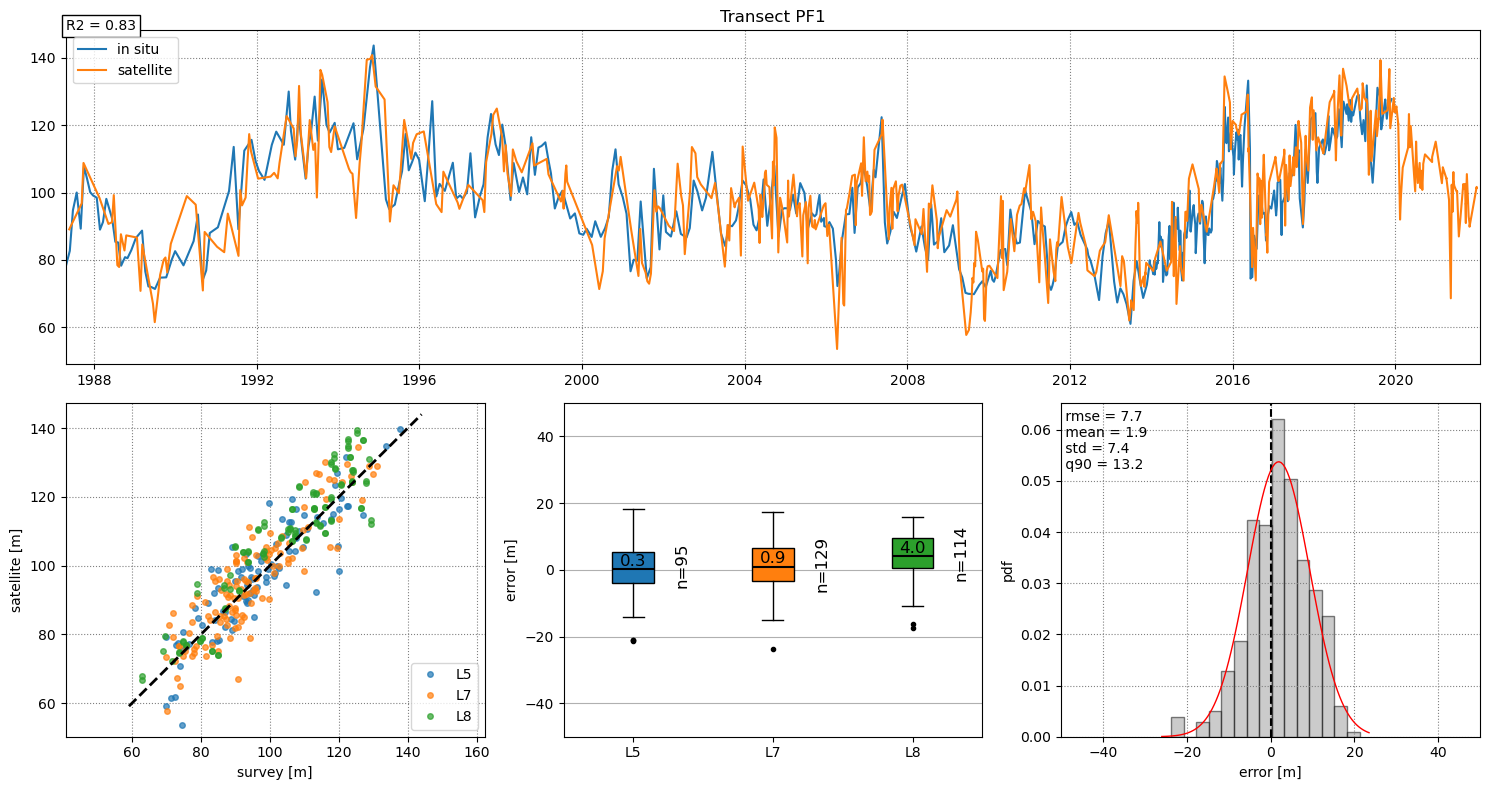

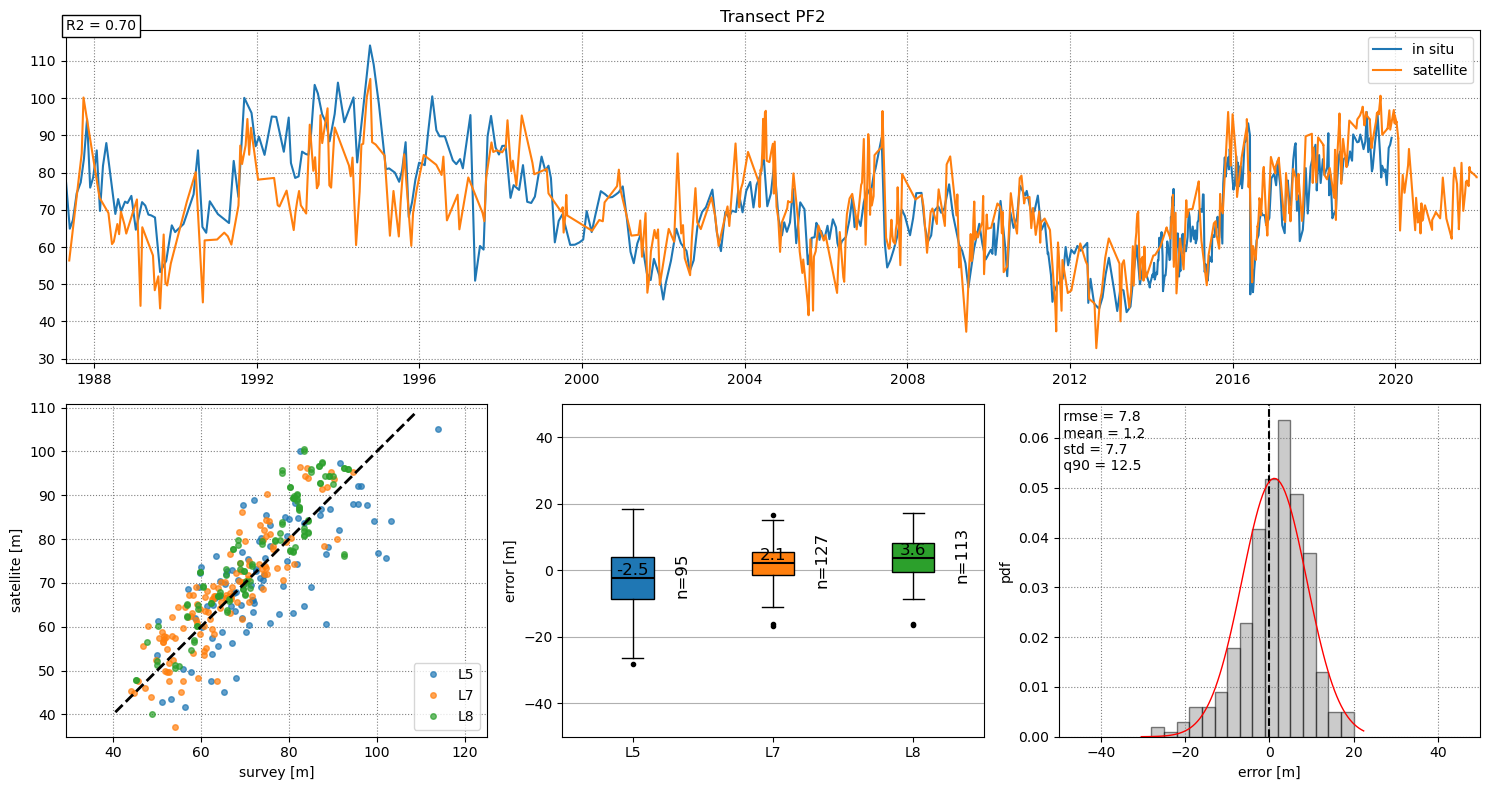

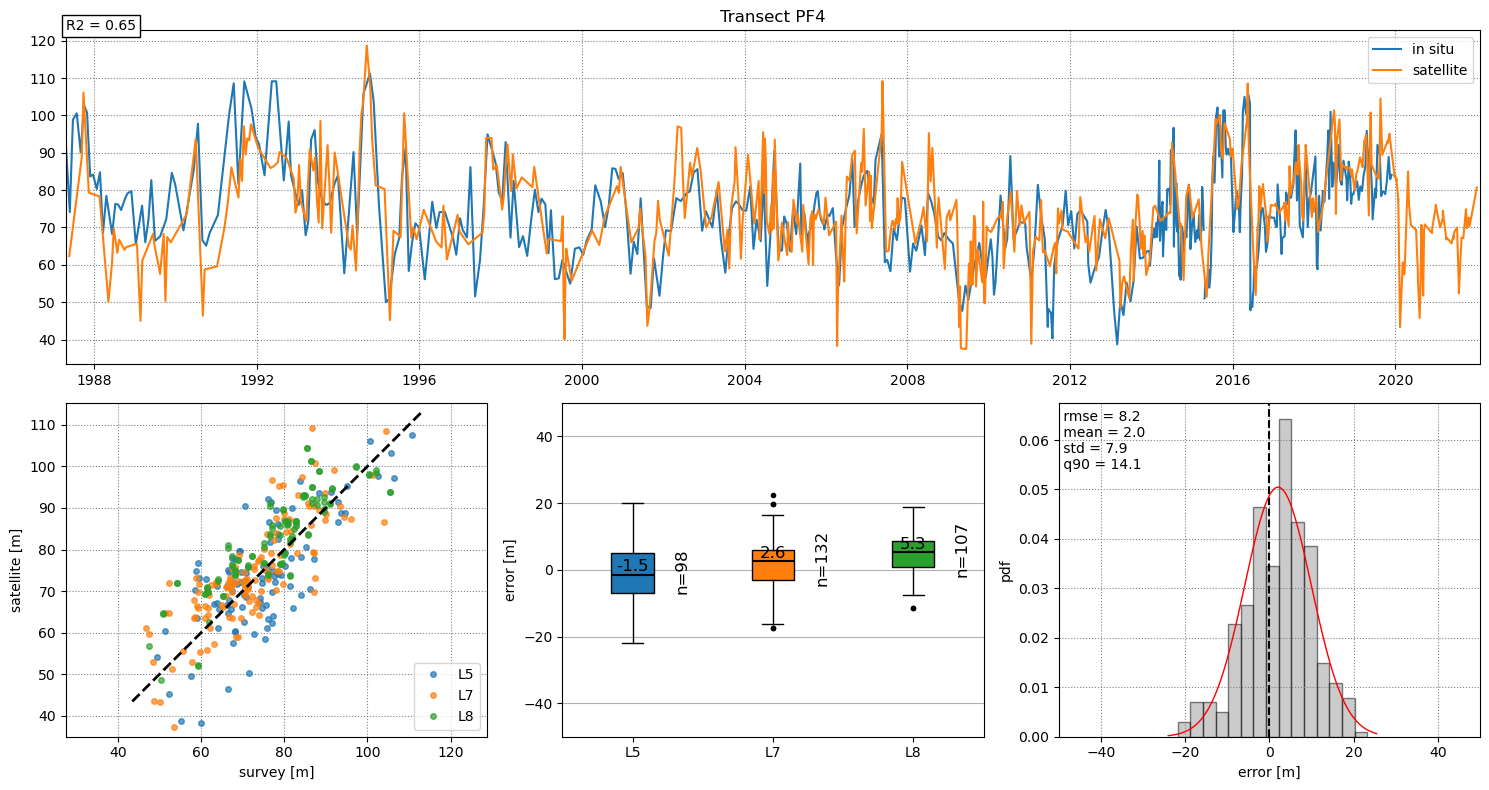

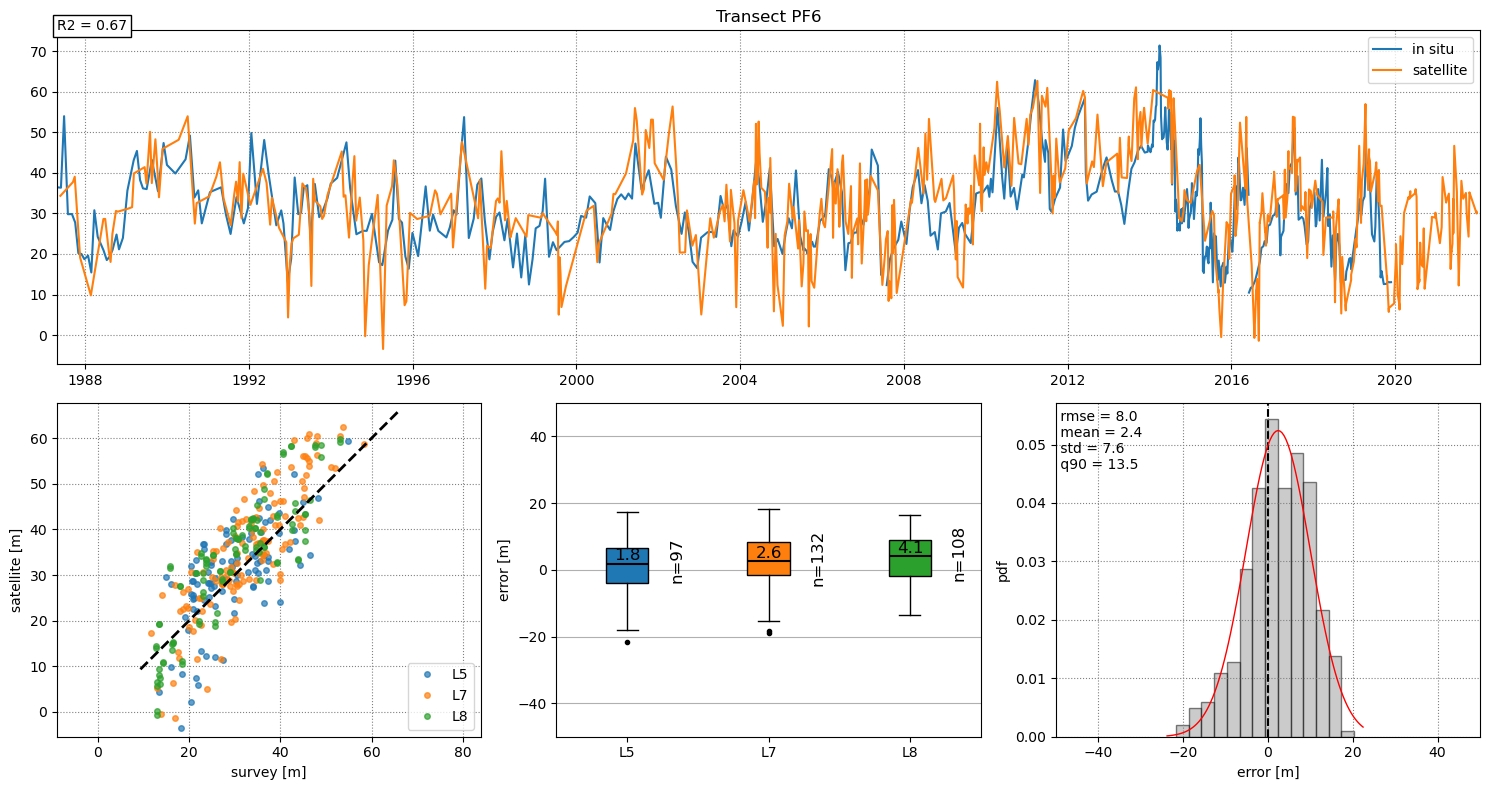

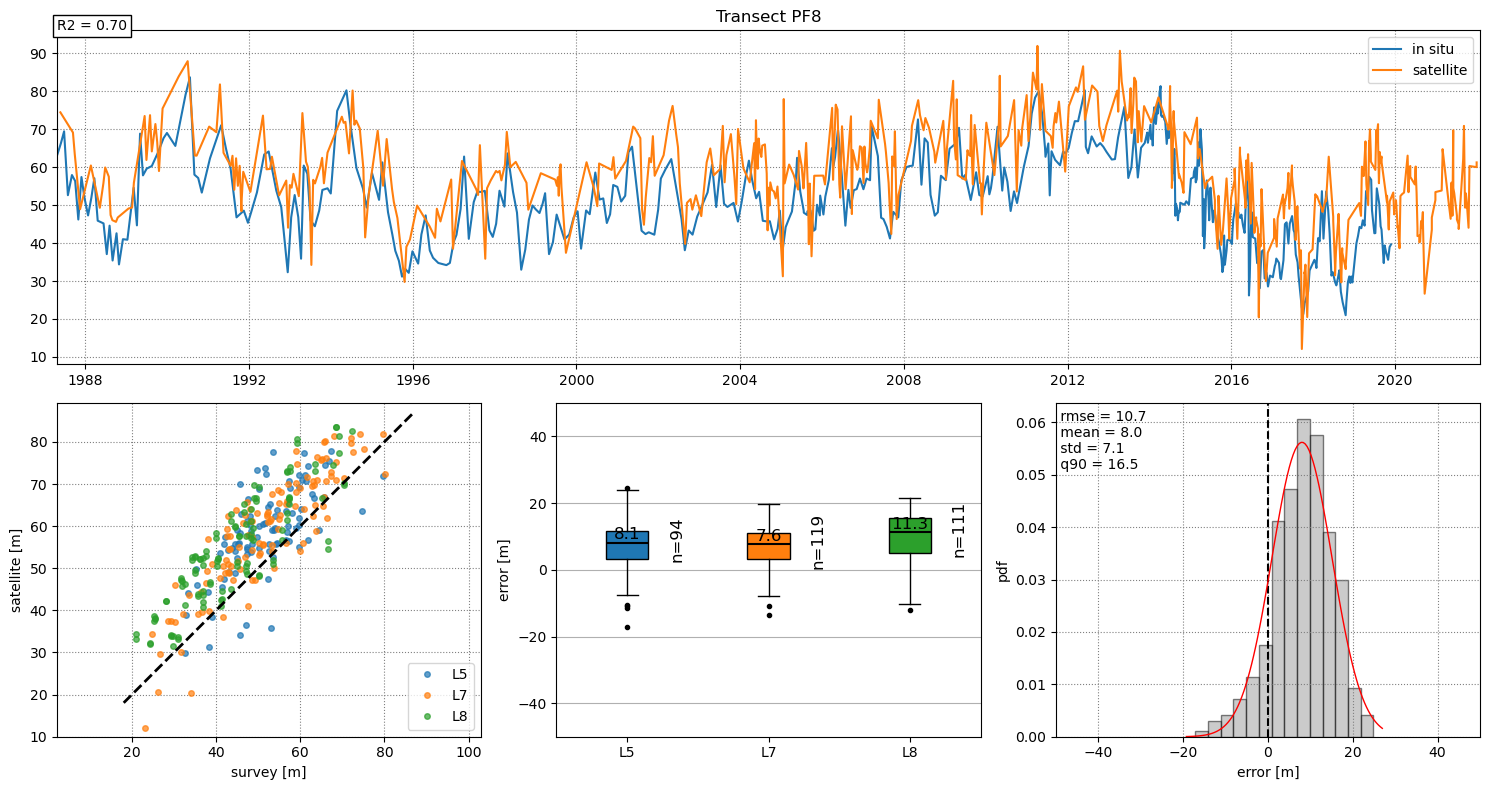

In [ ]:
# load survey data
with open(os.path.join(os.getcwd(), 'examples', 'Narrabeen_ts_07m.pkl'), 'rb') as f:
    gt = pickle.load(f)
# change names to mach surveys
for i,key in enumerate(list(cross_distance.keys())):
    key_gt = list(gt.keys())[i]
    cross_distance[key_gt] = cross_distance.pop(key)

# set parameters for comparing the two time-series
sett = {'min_days':3,   # numbers of days difference under which to use nearest neighbour interpolation
        'max_days':10,  # maximum number of days difference to do a comparison
        'binwidth':3,   # binwidth for histogram plotting
        'lims':[-50,50] # cross-shore change limits for plotting purposes
       }

# initialise variables
chain_sat_all = []
chain_sur_all = [] 
satnames_all = []  
for key in cross_distance.keys():
    
    # remove nans
    chainage = cross_distance[key]
    idx_nan = np.isnan(chainage)
    dates_nonans = [output['dates'][k] for k in np.where(~idx_nan)[0]]
    satnames_nonans = [output['satname'][k] for k in np.where(~idx_nan)[0]]
    chain_nonans = chainage[~idx_nan]
    
    chain_sat_dm = chain_nonans
    chain_sur_dm = gt[key]['chainages']
    
    # plot the time-series
    fig= plt.figure(figsize=[15,8], tight_layout=True)
    gs = gridspec.GridSpec(2,3)
    ax0 = fig.add_subplot(gs[0,:])
    ax0.grid(which='major',linestyle=':',color='0.5')
    ax0.plot(gt[key]['dates'], chain_sur_dm, '-',mfc='w',ms=5,label='in situ')
    ax0.plot(dates_nonans, chain_sat_dm,'-',mfc='w',ms=5,label='satellite')
    ax0.set(title= 'Transect ' + key, xlim=[output['dates'][0]-timedelta(days=30),
                                           output['dates'][-1]+timedelta(days=30)])#,ylim=sett['lims'])
    ax0.legend()
    
    # interpolate surveyed data around satellite data
    chain_int = np.nan*np.ones(len(dates_nonans))
    for k,date in enumerate(dates_nonans):
        # compute the days distance for each satellite date 
        days_diff = np.array([ (_ - date).days for _ in gt[key]['dates']])
        # if nothing within 10 days put a nan
        if np.min(np.abs(days_diff)) > sett['max_days']:
            chain_int[k] = np.nan
        else:
            # if a point within 3 days, take that point (no interpolation)
            if np.min(np.abs(days_diff)) < sett['min_days']:
                idx_closest = np.where(np.abs(days_diff) == np.min(np.abs(days_diff)))
                chain_int[k] = float(gt[key]['chainages'][idx_closest[0][0]])
            else: # otherwise, between 3 and 10 days, interpolate between the 2 closest points
                if sum(days_diff > 0) == 0:
                    break
                idx_after = np.where(days_diff > 0)[0][0]
                idx_before = idx_after - 1
                x = [gt[key]['dates'][idx_before].toordinal() , gt[key]['dates'][idx_after].toordinal()]
                y = [gt[key]['chainages'][idx_before], gt[key]['chainages'][idx_after]]
                f = interpolate.interp1d(x, y,bounds_error=True)
                chain_int[k] = float(f(date.toordinal()))
    
    # remove nans again
    idx_nan = np.isnan(chain_int)
    chain_sat = chain_nonans[~idx_nan]
    chain_sur = chain_int[~idx_nan]
    dates_sat = [dates_nonans[k] for k in np.where(~idx_nan)[0]]
    satnames = [satnames_nonans[k] for k in np.where(~idx_nan)[0]]
    chain_sat_all = np.append(chain_sat_all,chain_sat)
    chain_sur_all = np.append(chain_sur_all,chain_sur)
    satnames_all = satnames_all + satnames
    
    # error statistics
    slope, intercept, rvalue, pvalue, std_err = stats.linregress(chain_sur, chain_sat)
    R2 = rvalue**2 
    ax0.text(0,1,'R2 = %.2f'%R2,bbox=dict(boxstyle='square', facecolor='w', alpha=1),transform=ax0.transAxes)
    chain_error = chain_sat - chain_sur
    rmse = np.sqrt(np.mean((chain_error)**2))
    mean = np.mean(chain_error)
    std = np.std(chain_error)
    q90 = np.percentile(np.abs(chain_error), 90)
    
    # 1:1 plot
    ax1 = fig.add_subplot(gs[1,0])
    ax1.axis('equal')
    ax1.grid(which='major',linestyle=':',color='0.5')
    for k,sat in enumerate(list(np.unique(satnames))): 
        idx = np.where([_ == sat for _ in satnames])[0]
        ax1.plot(chain_sur[idx], chain_sat[idx], 'o', ms=4, mfc='C'+str(k),mec='C'+str(k), alpha=0.7, label=sat)
    ax1.legend(loc=4)
    ax1.plot([ax1.get_xlim()[0], ax1.get_ylim()[1]],[ax1.get_xlim()[0], ax1.get_ylim()[1]],'k--',lw=2)
    ax1.set(xlabel='survey [m]', ylabel='satellite [m]')

    # boxplots
    ax2 = fig.add_subplot(gs[1,1])
    data = []
    median_data = []
    n_data = []
    ax2.yaxis.grid()
    for k,sat in enumerate(list(np.unique(satnames))):
        idx = np.where([_ == sat for _ in satnames])[0]
        data.append(chain_error[idx])
        median_data.append(np.median(chain_error[idx]))
        n_data.append(len(chain_error[idx]))
    bp = ax2.boxplot(data,0,'k.', labels=list(np.unique(satnames)), patch_artist=True)
    for median in bp['medians']:
        median.set(color='k', linewidth=1.5)
    for j,boxes in enumerate(bp['boxes']):
        boxes.set(facecolor='C'+str(j))
        ax2.text(j+1,median_data[j]+1, '%.1f' % median_data[j], horizontalalignment='center', fontsize=12)
        ax2.text(j+1+0.35,median_data[j]+1, ('n=%.d' % int(n_data[j])), ha='center', va='center', fontsize=12, rotation='vertical')
    ax2.set(ylabel='error [m]', ylim=sett['lims'])
    
    # histogram
    ax3 = fig.add_subplot(gs[1,2])
    ax3.grid(which='major',linestyle=':',color='0.5')
    ax3.axvline(x=0, ls='--', lw=1.5, color='k')
    binwidth=sett['binwidth']
    bins = np.arange(min(chain_error), max(chain_error) + binwidth, binwidth)
    density = plt.hist(chain_error, bins=bins, density=True, color='0.6', edgecolor='k', alpha=0.5)
    mu, std = stats.norm.fit(chain_error)
    pval = stats.normaltest(chain_error)[1]
    xlims = ax3.get_xlim()
    x = np.linspace(xlims[0], xlims[1], 100)
    p = stats.norm.pdf(x, mu, std)
    ax3.plot(x, p, 'r-', linewidth=1)
    ax3.set(xlabel='error [m]', ylabel='pdf', xlim=sett['lims'])   
    str_stats = ' rmse = %.1f\n mean = %.1f\n std = %.1f\n q90 = %.1f' % (rmse, mean, std, q90) 
    ax3.text(0, 0.98, str_stats,va='top', transform=ax3.transAxes)
    
    # save plot
    fig.savefig(os.path.join(os.getcwd(),'examples','comparison_transect_%s.jpg'%key), dpi=150)


We can also look at the error statistics for all transects:

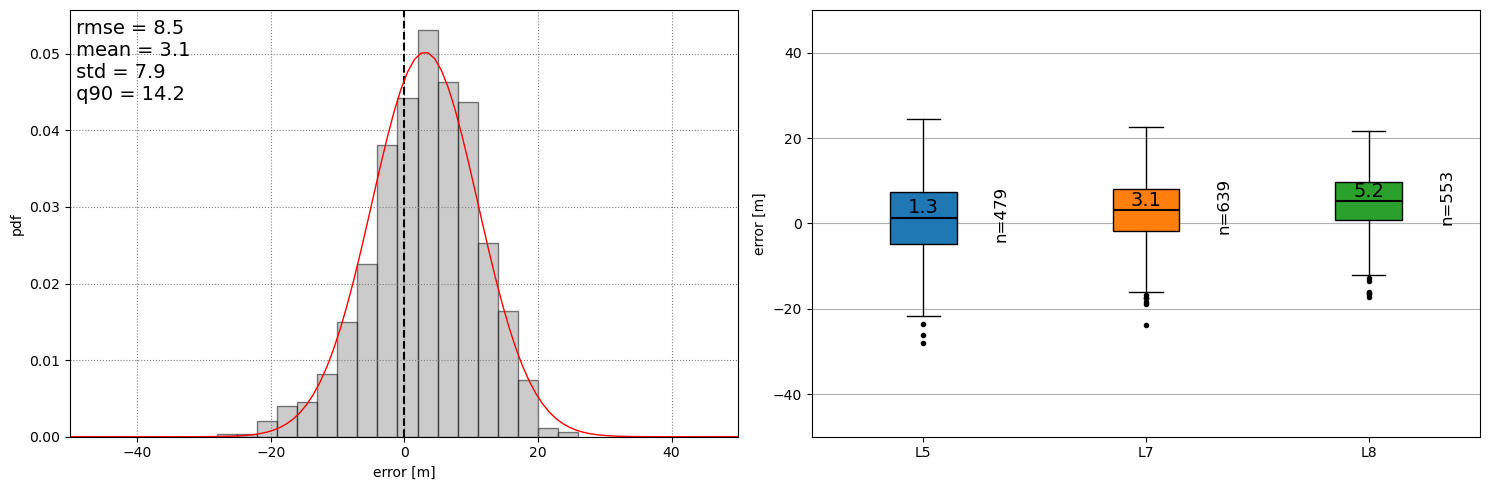

In [ ]:
# calculate statistics for all transects together
chain_error = chain_sat_all - chain_sur_all        
slope, intercept, rvalue, pvalue, std_err = stats.linregress(chain_sur, chain_sat) 
R2 = rvalue**2
rmse = np.sqrt(np.mean((chain_error)**2))
mean = np.mean(chain_error)
std = np.std(chain_error)
q90 = np.percentile(np.abs(chain_error), 90)

fig,ax = plt.subplots(1,2,figsize=(15,5), tight_layout=True)
# histogram
ax[0].grid(which='major',linestyle=':',color='0.5')
ax[0].axvline(x=0, ls='--', lw=1.5, color='k')
binwidth=sett['binwidth']
bins = np.arange(min(chain_error), max(chain_error) + binwidth, binwidth)
density = ax[0].hist(chain_error, bins=bins, density=True, color='0.6', edgecolor='k', alpha=0.5)
mu, std = stats.norm.fit(chain_error)
pval = stats.normaltest(chain_error)[1]
xlims = ax3.get_xlim()
x = np.linspace(xlims[0], xlims[1], 100)
p = stats.norm.pdf(x, mu, std)
ax[0].plot(x, p, 'r-', linewidth=1)
ax[0].set(xlabel='error [m]', ylabel='pdf', xlim=sett['lims'])   
str_stats = ' rmse = %.1f\n mean = %.1f\n std = %.1f\n q90 = %.1f' % (rmse, mean, std, q90) 
ax[0].text(0, 0.98, str_stats,va='top', transform=ax[0].transAxes,fontsize=14)

# boxplot
data = []
median_data = []
n_data = []
ax[1].yaxis.grid()
for k,sat in enumerate(list(np.unique(satnames_all))):
    idx = np.where([_ == sat for _ in satnames_all])[0]
    data.append(chain_error[idx])
    median_data.append(np.median(chain_error[idx]))
    n_data.append(len(chain_error[idx]))
bp = ax[1].boxplot(data,0,'k.', labels=list(np.unique(satnames_all)), patch_artist=True)
for median in bp['medians']:
    median.set(color='k', linewidth=1.5)
for j,boxes in enumerate(bp['boxes']):
    boxes.set(facecolor='C'+str(j))
    ax[1].text(j+1,median_data[j]+1, '%.1f' % median_data[j], horizontalalignment='center', fontsize=14)
    ax[1].text(j+1+0.35,median_data[j]+1, ('n=%.d' % int(n_data[j])), ha='center', va='center', fontsize=12, rotation='vertical')
ax[1].set(ylabel='error [m]', ylim=sett['lims']);
fig.savefig(os.path.join(os.getcwd(),'examples','comparison_all_transects.jpg'), dpi=150)